In [1]:
import glob
import xarray as xr
import xugrid as xu
import numpy as np
import matplotlib.pyplot as plt
import os
import gc

parent_dir = '/media/cassandra/Expansion/2026-09-29-Stillaguamish/'
model_dirs = glob.glob(parent_dir + 'reanalysis/S*/')
years = np.arange(1990, 2017, 1)

/home/cassandra/anaconda3/envs/hydromt-sfincs-test/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load & Concatenate Model Map Output

In [2]:
qtr_file = parent_dir + 'sfincs.nc'
qtr = xr.open_dataset(qtr_file)
mesh2d_nFaces = qtr.mesh2d_nFaces.values

sbg_file = parent_dir +  'sfincs_subgrid.nc'
sbg = xr.open_dataset(sbg_file)
zmin = sbg.z_zmin.values

In [52]:
# Prep empty arrays for model output
zsmax    = np.ndarray((len(years)*365,len(mesh2d_nFaces)),  dtype=np.dtype('float32'))
ztime    = np.ndarray((len(years)*365),                     dtype=np.dtype('datetime64[D]'))
for yi in range(len(years)):
    print("Reading output from", years[yi])

    # Timestep first
    # Note the timestep assumes water years (October, year-1 through October, year) + a 7 day buffer at start
    maptime = np.datetime64(str(years[yi]-1) + '-09-24T00:00:00') + np.arange(0, 365+7, 1)*np.timedelta64(1, 'D')
    # Cut 7 days at the start, and up to 1 day at the end 
    # dropping a day in leap years, should fix that later
    ztime[  yi*365:(yi+1)*365] = maptime[7:365+7]

    # Check if file exists
    map_file = model_dirs[yi] + '/sfincs_map.nc'
    if not os.path.exists(map_file):
        continue
    smap = xr.open_dataset(map_file, decode_times=False, engine='netcdf4')

    # Runs that finished prematurely must be carefully read...
    mapzmax = np.ones((len(smap.timemax), len(mesh2d_nFaces))) * np.nan
    for i in range(len(smap.timemax)):
        try: 
            # Access model output at this timestep
            mapzmax[i] = smap.zsmax[i].values.astype(np.float32)
            # Set NANs to the subgrid zs zmin
            nanmask = np.isnan(mapzmax[i])
            mapzmax[i][nanmask] = zmin[nanmask]
        except RuntimeError as e:  break
    zsmax[  yi*365:(yi+1)*365] = mapzmax[7:365+7]
    gc.collect()
# Save Result
d = { "coords": {"timemax"      : {"dims": "timemax",       "data": ztime},
                 "mesh2d_nFaces": {"dims": "mesh2d_nFaces", "data": mesh2d_nFaces}},
      "dims":  ["timemax", "mesh2d_nFaces"],
      "data_vars": {"zmax" : {"dims": ["timemax", "mesh2d_nFaces"], "data": zsmax}}}
ds = xr.Dataset.from_dict(d)
ds.to_netcdf(parent_dir + 'combined_zsmax.nc')

Reading output from 1990
Reading output from 1991
Reading output from 1992
Reading output from 1993
Reading output from 1994
Reading output from 1995
Reading output from 1996
Reading output from 1997
Reading output from 1998
Reading output from 1999
Reading output from 2000
Reading output from 2001
Reading output from 2002
Reading output from 2003
Reading output from 2004
Reading output from 2005
Reading output from 2006
Reading output from 2007
Reading output from 2008
Reading output from 2009
Reading output from 2010
Reading output from 2011
Reading output from 2012
Reading output from 2013
Reading output from 2014
Reading output from 2015
Reading output from 2016


### Sanity Check

In [71]:
# Get grid info from the quadtree file
qtr_file = parent_dir + 'sfincs.nc'
qtr = xr.open_dataset(qtr_file)
bx = qtr.mesh2d_node_x.values
by = qtr.mesh2d_node_y.values
i = qtr.mesh2d_face_nodes.values.astype(int)
lev = qtr.level.values
# Get the grid spacing
qdx = qtr.dx / (2** (lev - 1))
qdy = qtr.dy / (2** (lev - 1))
# Get the corners
x0, y0 = [], []
for j in range(len(i)):
    x0.append(bx[i[j][0]])
    y0.append(by[i[j][0]])
x0 = np.array(x0)
y0 = np.array(y0)
# Get the centers
xc, yc = x0 + qdx/2, y0 + qdy/2

/tmp/ipykernel_97673/3639075674.py:8: RuntimeWarning: invalid value encountered in cast
  i = qtr.mesh2d_face_nodes.values.astype(int)


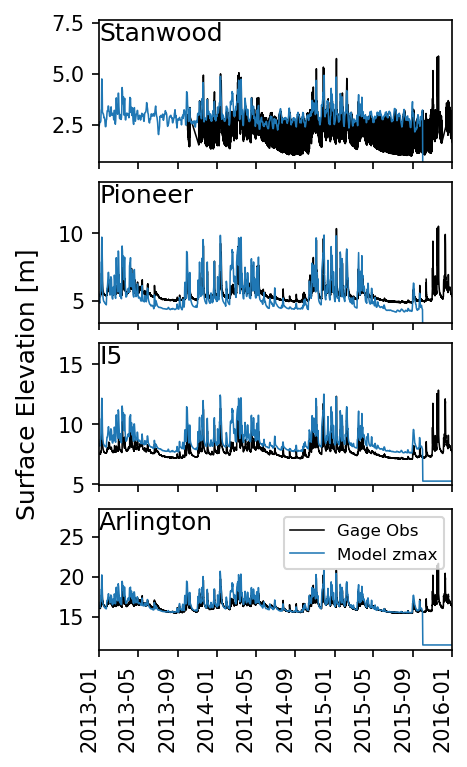

In [91]:
import utm

# Gage compilation file
gages = xr.open_dataset('/home/cassandra/Data/stil_gages.nc')

# Plot each gage and nearest map point (zsmax)
fig, axs = plt.subplots(nrows=len(gages.station), sharex=True, figsize=(3,5), dpi=150, constrained_layout=True)
for si in range(len(gages.station)):
    slat, slon = gages.lat[si].values, gages.lon[si].values
    sx, sy, _, __ = utm.from_latlon(slat, slon)
    qi = np.argmin(np.sqrt((sx-xc)**2 + (sy-yc)**2))
    gage_name = str(gages.station[si].values)

    axs[si].set_title(gage_name, loc='left', y=1.0, pad=-10)
    axs[si].plot(gages.time.values, gages.z[:,si].values, label='Gage Obs', linewidth=0.75, color='black')
    axs[si].plot(ztime, zsmax[:,qi], label='Model zmax', linewidth=0.75)
    axs[si].set_ylim(np.nanmin(gages.z[:,si].values)*0.7, np.nanmax(gages.z[:,si].values)*1.3)
plt.xlim(np.datetime64('2013'), np.datetime64('2016'))    
fig.autofmt_xdate(bottom=0.2, rotation=90, ha='right')
fig.supylabel("Surface Elevation [m]")
axs[-1].legend(fontsize=8, loc='upper right', ncol=1)
plt.show()

### Compute Quick RI Stats

In [35]:
import scipy
import matplotlib.pyplot as plt

# Interval years to search
intervals = [1, 5, 10] #, 20, 30]
thresholds = [[] for interval in intervals]
n_years = len(years) #32 #10 #the number simulated
num_events = [len(years), int(len(years)/5), int(len(years)/10)] 
# Search distance for peaks: minimum 4 days between peaks
dist = 4 

# For each quadtree cell, detect peaks for each interval
print("Computing Peak Over Threshold Statistics")
# Progress bar
for j in range(len(mesh2d_nFaces)):
    if j % 10000 == 0: print('_',end='')
print('')
for j in range(len(mesh2d_nFaces)):
    if j % 10000 == 0: print('.',end='')
    # Search for peaks within 4 days -- 
    # 4 days is based on decorrelation lengthscale of discharge boundary time series...
    peaks, _ = scipy.signal.find_peaks(zsmax[:,j], distance=dist)
    # If no peaks, skip (add nans)
    if len(peaks) < 0:
        for i in range(len(intervals)):
            thresholds[i].append(np.nan)
    # Otherwise, look at the order of the peaks
    else:
        peakvals = zsmax[peaks,j]
        order = np.argsort(peakvals)
        # For each interval (1 year, 5 years, 10 years, etc)...
        for i in range(len(intervals)):
            N = num_events[i]
            # If there are fewer peaks than the associated number of events (n years / interval)
            # Then skip (add nans)
            if len(peakvals) < N:
                thresholds[i].append(np.nan)
            # Otherwise navigate to the Nth largest event, 
            # where N is the number of events to be above the threshold...
            else:
                thresholds[i].append(peakvals[order[-1 * N]])
thresholds = np.array(thresholds)

# Save Result
d = { "coords": {"mesh2d_nFaces" : {"dims": "mesh2d_nFaces", "data": mesh2d_nFaces},
                 "years_interval": {"dims": "years_interval","data": intervals}},
      "dims":  ["years_interval", "mesh2d_nFaces"],
      "data_vars": {"zsmax" : {"dims": ["years_interval", "mesh2d_nFaces"], "data": thresholds}}}
ds = xr.Dataset.from_dict(d)
ds.to_netcdf(parent_dir + 'zsmax_thresholds.nc')

Computing Peak Over Threshold Statistics
_________
.........

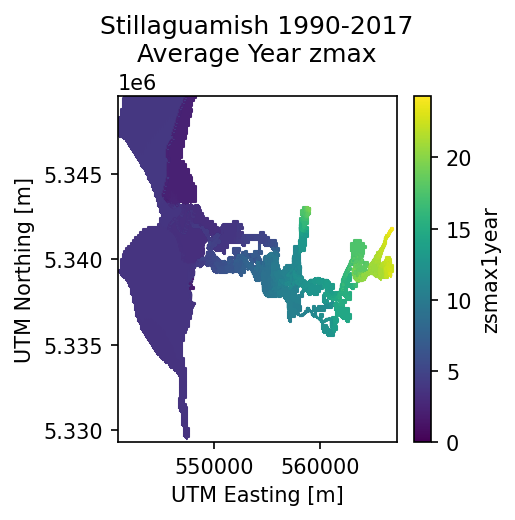

In [36]:
import xugrid as xu

x_qtr = xu.load_dataset(qtr_file)
x_qtr['zsmax1year']    = (('mesh2d_nFaces'), ds.zsmax[0].values)

fig = plt.figure(figsize=(3,3), dpi=150)
ax = plt.subplot(111)
x_qtr.zsmax1year.ugrid.plot(vmin=0, ax=ax)
plt.xlabel("UTM Easting [m]")
plt.ylabel("UTM Northing [m]")
plt.title("Stillaguamish 1990-2017\nAverage Year zmax")
plt.show()

## Simple Downscaling

In [93]:
ds = xr.open_dataset(parent_dir + 'zsmax_thresholds.nc')

# DEM Info
DEM_tif = '/home/cassandra/Data/CoNED_Stilly_Block_w_SnoCoNatRes_terrain_SfM_debridged.tif'
bdx, bdy = 1, 1
window_size = 8*1024

In [96]:
import rasterio
from rasterio.windows import Window
from rasterio.features import shapes
from rasterio.windows import transform as window_transform
from rasterio.transform import xy
import numpy as np
import geopandas as gpd
import xarray as xr
import gc
from shapely.geometry import shape

# For each return interval...
for zsmax, year in zip(ds.zsmax.values, ds.years_interval.values):
    # Nan out dry cells
    zsmax[zsmax <= zmin] = np.nan
    # Set out path
    out_tif = parent_dir + str(year) + 'year_hmax.tif'
    print('\n' + out_tif)
    # Open the DEM...
    with rasterio.open(DEM_tif) as src:
        profile = src.profile.copy()
        crs = src.crs
        # Open the output geotiff, copy DEM metadata
        with rasterio.open(out_tif, 'w', **profile) as dst:
            # Iterate over windows
            for wyi in range(0, src.height, int(window_size)):
                # progress bar
                print('')
                print("Chunk", int(wyi/window_size)+1, 'of', int(src.height/window_size)+1)
                for wxi in range(0, src.width, int(window_size)):
                    print('_',end='')
                print('')
                for wxi in range(0, src.width, int(window_size)):
                    print('.',end='')
                    # Window and get data
                    w = Window(wxi, wyi,
                               min(window_size, src.width - wxi),
                               min(window_size, src.height - wyi))
                    zb = src.read(window=w)
                    # Read x, y - note, that this assumes the DEM is not rotated 
                    # relative to model coordinate system
                    rows = np.arange(w.height)
                    cols = np.arange(w.width)
                    # Compute x coordinates (center of each column)
                    win_transform = src.window_transform(w)
                    x, _ = xy(win_transform, 0 * np.ones_like(cols), cols, offset='center')
                    # Compute y coordinates (center of each row)
                    _, y = xy(win_transform, rows, 0 * np.ones_like(rows), offset='center')
                    x = np.array(x)
                    y = np.array(y)
                    # For each quadtree grid cell, locate and assign the relevant bathy indices (point from bathy --> quadtree)
                    qi = np.int64(list(range(len(qtr.mesh2d_nFaces))))
                    xi0 = np.int64((x0 - x[0]) / bdx)
                    yi0t = np.int64((y0 - y[-1]) / bdy)
                    xif = np.int64((x0 + qdx - x[0]) / bdx)
                    yift = np.int64((y0 + qdy - y[-1]) / bdy)
                    # flip y axis... I think...
                    yif = -1 * yi0t + len(y) 
                    yi0 = -1 * yift + len(y)
                    # Check what intersects the area of interest -- full quadtree cells only
                    qok = np.logical_and(np.logical_and(xif >= 0, xi0 < len(x)),
                                         np.logical_and(yif >= 0, yi0 < len(y)))
                    # and non-nan values only
                    qok = np.logical_and(qok, ~np.isnan(zsmax))
                    # Access model output
                    flood_depth = np.zeros(zb.shape)*np.nan
                    for i in qi[qok]:
                        for xi in range(xi0[i],xif[i]):
                            if xi >= len(x) or xi < 0:
                                continue
                            for yi in range(yi0[i], yif[i]):
                                if yi >= len(y) or yi < 0:
                                    continue
                                flood_depth[0,yi,xi] = zsmax[i] - zb[0,yi,xi]
                    flood_depth[flood_depth < 0.01] = np.nan
                    # Write to new geotif
                    dst.write(flood_depth, window=w)
                    # collect to try to keep memory leaks under control
                    gc.collect()


/media/cassandra/Expansion/2026-09-29-Stillaguamish/1year_hmax.tif

Chunk 1 of 4
_____
.....
Chunk 2 of 4
_____
.....
Chunk 3 of 4
_____
.....
Chunk 4 of 4
_____
.....
/media/cassandra/Expansion/2026-09-29-Stillaguamish/5year_hmax.tif

Chunk 1 of 4
_____
.....
Chunk 2 of 4
_____
.....
Chunk 3 of 4
_____
.....
Chunk 4 of 4
_____
.....
/media/cassandra/Expansion/2026-09-29-Stillaguamish/10year_hmax.tif

Chunk 1 of 4
_____
.....
Chunk 2 of 4
_____
.....
Chunk 3 of 4
_____
.....
Chunk 4 of 4
_____
.....

## Plot Grid & Levee

In [187]:
from shapely.geometry import LineString
import geopandas as gpd

## Read levees
weirfile = parent_dir + 'sfincs.weir'

x, y, z = [], [], []
tx, ty, tz = [], [], []
pass_next = False
with open(weirfile, 'r') as w:
    for line in w.readlines():
        if pass_next:
            pass_next = False
        elif 'weir' in line:
            if len(tx) > 0:
                x.append(tx), y.append(ty), z.append(tz)
            tx, ty, tz = [], [], []
            pass_next = True
        else:
            xx, yy, zz, dd = line.split()
            tx.append(float(xx)), ty.append(float(yy)), tz.append(float(zz))

lines = []
for xx,yy in zip(x,y):
    lines.append(LineString(list(zip(xx, yy))))
# Create GeoDataFrame
gdf = gpd.GeoDataFrame({'z':z}, geometry=lines)

In [180]:
x_qtr['mesh2d_nEdges'] = (('mesh2d_nEdges'), qtr.mesh2d_nEdges.values)

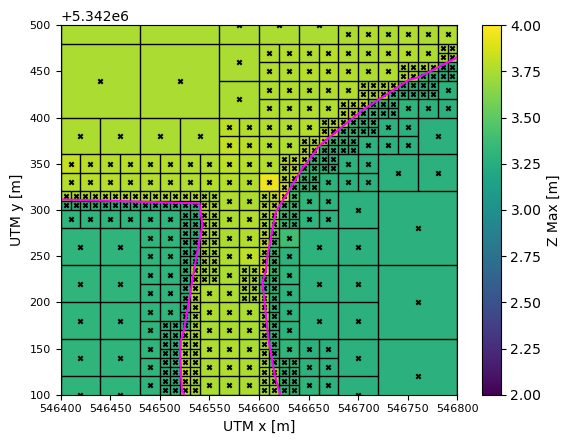

In [181]:
fig, ax = plt.subplots()

# Plot zmax
mesh = x_qtr['zsmax1year'].ugrid.plot(ax=ax, vmin=2, vmax=4, add_colorbar=False)
cb = plt.colorbar(mesh)
cb.ax.set_ylabel("Z Max [m]")

# Plot the quadtree grid edges
x_qtr.mesh2d_nEdges.ugrid.plot(color='black', add_colorbar=False, linewidth=1)

# Plot levee
for g in gdf.geometry:
    x,y = g.xy
    plt.plot(x, y, color='magenta')

# Plot grid centers
plt.scatter(xc, yc, color='black', marker='x', s=10)

xmid = 546600
ymid = 5342300
lim_dist = 200
plt.xlim(xmid-lim_dist, xmid+lim_dist)
plt.ylim(ymid-lim_dist, ymid+lim_dist)
plt.xlabel("UTM x [m]")
plt.ylabel("UTM y [m]")
plt.tick_params(labelsize=8)
plt.show()

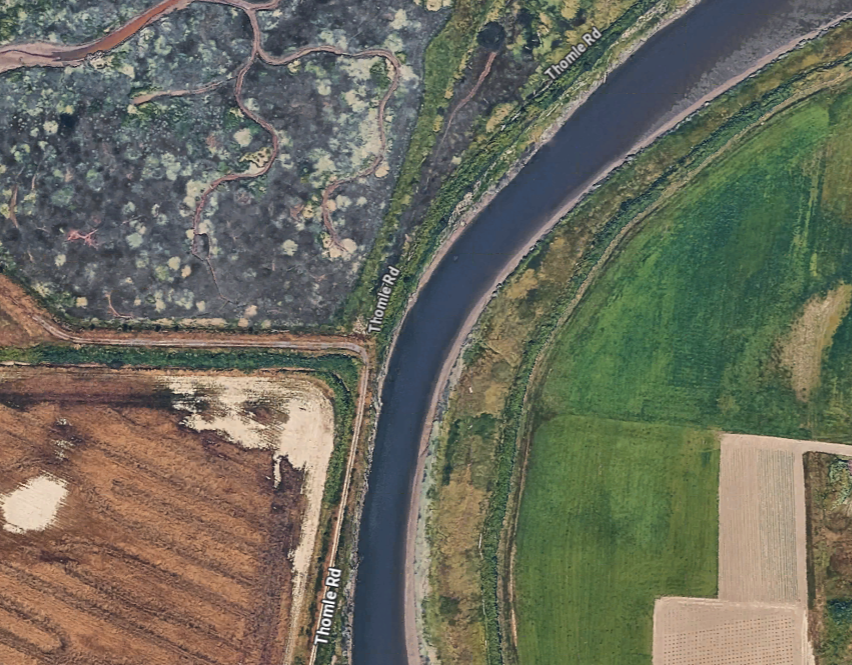

## Create Levee Buffers and Divide

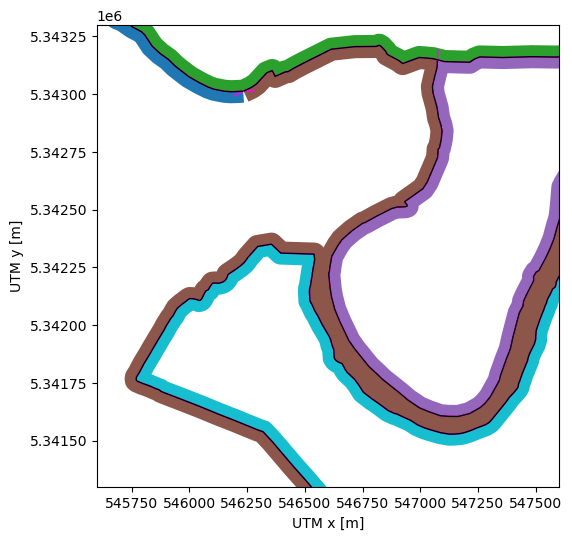

In [211]:
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString
from shapely.ops import unary_union, polygonize
import random

DIST = 50

# 1. Buffer around the linestrings (round caps, so the ends are covered by DIST too)
gdf["buffer"] = gdf.geometry.buffer(DIST, cap_style='flat')
buffer_union = unary_union(gdf["buffer"].tolist())

# 2. Extend each linestring's ends straight out by DIST, following the direction of the end segments
extended = []
for line in gdf.geometry:
    coords = np.asarray(line.coords)
    start_dir = coords[0] - coords[1]
    end_dir = coords[-1] - coords[-2]
    new_start = coords[0] + start_dir / np.linalg.norm(start_dir) * DIST
    new_end = coords[-1] + end_dir / np.linalg.norm(end_dir) * DIST
    extended.append(LineString(np.vstack([new_start, coords, new_end])))
gdf["extended"] = gpd.GeoSeries(extended, index=gdf.index, crs=gdf.crs)

# 3. Divide the buffers with the (extended) linestrings.
#    Node the buffer boundary together with all extended lines, polygonize the result,
#    and keep only faces that lie inside the buffer (drops enclosed gaps between lines).
noded = unary_union([buffer_union.boundary] + extended)
pieces = [p for p in polygonize(noded) if buffer_union.contains(p.representative_point())]

result = gpd.GeoDataFrame({"piece_id": range(len(pieces))}, geometry=pieces, crs=gdf.crs)

# Record which source line(s) each piece borders
lines_sindex = gdf.geometry.buffer(1e-6)
result["source_lines"] = [list(gdf.index[lines_sindex.intersects(p)]) for p in result.geometry]

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = random.sample(prop_cycle.by_key()['color']*10, len(result))

# Optional quick look:
ax = result.plot(color=colors, figsize=(10, 6))
gdf['extended'].plot(ax=ax, color="magenta", linewidth=1)
gdf.geometry.plot(ax=ax, color="black", linewidth=1)
xmid = 546600
ymid = 5342300

# xmid = 557200
# ymid = 5339000

lim_dist = 1000
plt.xlim(xmid-lim_dist, xmid+lim_dist)
plt.ylim(ymid-lim_dist, ymid+lim_dist)
plt.xlabel("UTM x [m]")
plt.ylabel("UTM y [m]")
plt.show()

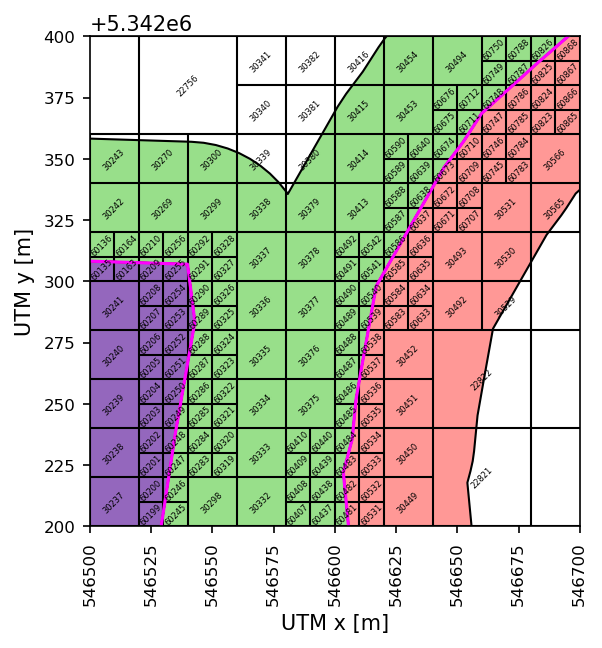

In [208]:
fig, ax = plt.subplots(figsize=(4,4), constrained_layout=True, dpi=150)

result.plot(column="piece_id", cmap="tab20", edgecolor="k", ax=ax)
gdf.set_geometry("extended").plot(ax=ax, color="red", linewidth=1)

# Plot the quadtree grid edges
x_qtr.mesh2d_nEdges.ugrid.plot(color='black', add_colorbar=False, linewidth=1)

# Plot levee
for g in gdf.geometry:
    x,y = g.xy
    plt.plot(x, y, color='magenta')

xmid = 546600
ymid = 5342300
lim_dist = 100
plt.xlim(xmid-lim_dist, xmid+lim_dist)
plt.ylim(ymid-lim_dist, ymid+lim_dist)

# Plot grid centers
in_xlim = np.logical_and(xc > xmid-lim_dist, xc < xmid+lim_dist)
in_ylim = np.logical_and(yc > ymid-lim_dist, yc < ymid+lim_dist)
in_lim = np.logical_and(in_xlim, in_ylim)

for x,y,i in zip(xc[in_lim], yc[in_lim], np.arange(0, len(xc), 1)[in_lim]):
    plt.text(x,y,i,fontsize=4,rotation=45,
        horizontalalignment='center',
        verticalalignment='center')

plt.xlabel("UTM x [m]")
plt.ylabel("UTM y [m]")
plt.tick_params(labelsize=8)
plt.xticks(rotation=90)
plt.show()

## Smart Index

### Step 1: Find Intersections

In [216]:
# Get each face as a polygon
zmax_gdf = x_qtr['zsmax1year'].ugrid.to_geodataframe()

# Test if each mesh intersects each levee
intersects = np.zeros(len(zmax_gdf), dtype=bool)
for i, levee_geometry in enumerate(gdf.geometry):
    intersects = np.logical_or(intersects, [levee_geometry.intersects(mesh) for mesh in zmax_gdf.geometry])

#### Plot Intersections

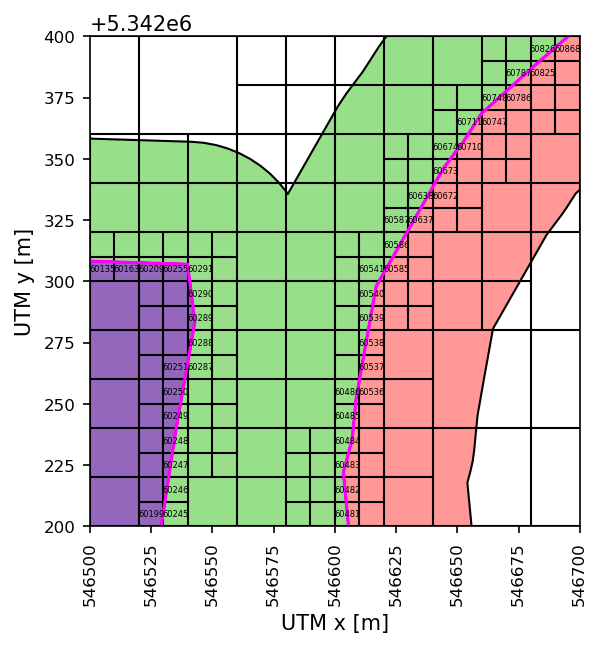

In [218]:
fig, ax = plt.subplots(figsize=(4,4), constrained_layout=True, dpi=150)

result.plot(column="piece_id", cmap="tab20", edgecolor="k", ax=ax)
gdf.set_geometry("extended").plot(ax=ax, color="red", linewidth=1)

# Plot the quadtree grid edges
x_qtr.mesh2d_nEdges.ugrid.plot(color='black', add_colorbar=False, linewidth=1)

# Plot levee
for g in gdf.geometry:
    x,y = g.xy
    plt.plot(x, y, color='magenta')

xmid = 546600
ymid = 5342300
lim_dist = 100
plt.xlim(xmid-lim_dist, xmid+lim_dist)
plt.ylim(ymid-lim_dist, ymid+lim_dist)

# Plot grid centers
in_xlim = np.logical_and(xc > xmid-lim_dist, xc < xmid+lim_dist)
in_ylim = np.logical_and(yc > ymid-lim_dist, yc < ymid+lim_dist)
in_lim = np.logical_and(in_xlim, in_ylim)

for x,y,i in zip(xc[in_lim], yc[in_lim], np.arange(0, len(xc), 1)[in_lim]):
    if intersects[i]:
        plt.text(x,y,i,fontsize=4,
            horizontalalignment='center',
            verticalalignment='center')

plt.xlabel("UTM x [m]")
plt.ylabel("UTM y [m]")
plt.tick_params(labelsize=8)
plt.xticks(rotation=90)
plt.show()

### Step 2: Index Sub-Pixel to Nearest Non-Intersected Pixel on Correct Side

In [262]:
from shapely import Point

# Get the zones
smart_zones = result.geometry.values
points = gpd.GeoDataFrame(geometry=[Point(x,y) for x,y in zip(xc,yc)])

# Get the quadtree points in each zone (non-intersecting)
zqx, zqy, zqi = [], [], []
for sz in smart_zones:
    in_zone = np.logical_and(sz.contains(points).values[:,0], ~intersects)

    # Event of no points
    if np.sum(in_zone) == 0:
        zqi.append(np.nan)
        zqx.append([])
        zqy.append([])

    else:
        zqi.append(np.where(in_zone)[0])
        zone_points = points[in_zone]
        zqx.append(zone_points.geometry.x.values)
        zqy.append(zone_points.geometry.y.values)

# Prepare to point to the nearest quadtree point in the same zone
def smart_index(x,y):

    # Find the zone for this point
    zi = np.where(smart_zones.contains(Point(x,y)))[0][0]

    # Get the closest point in the zone
    di = np.argmin(np.sqrt((x - zqx[zi])**2 + (y - zqy[zi])**2))

    # Return that quadtree index
    return zqi[zi][di]

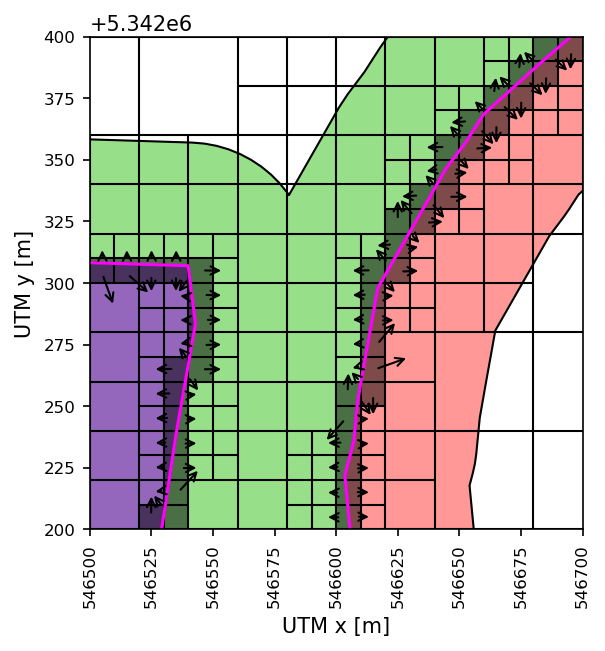

In [274]:
from shapely.ops import unary_union, polygonize
from shapely.geometry import MultiLineString

def split_polygon(pixel, lines):
    # accept a list of LineStrings or a MultiLineString
    if isinstance(lines, MultiLineString):
        lines = list(lines.geoms)
    # union nodes all lines + the polygon boundary at every intersection
    noded = unary_union([pixel.boundary, *lines])
    # build every closed face, keep only those inside the original polygon
    return [p for p in polygonize(noded) if pixel.contains(p.representative_point())]
    

fig, ax = plt.subplots(figsize=(4,4), constrained_layout=True, dpi=150)

result.plot(column="piece_id", cmap="tab20", edgecolor="k", ax=ax)
gdf.set_geometry("extended").plot(ax=ax, color="red", linewidth=1)

# Plot the quadtree grid edges
x_qtr.mesh2d_nEdges.ugrid.plot(color='black', add_colorbar=False, linewidth=1)

# Plot levee
for g in gdf.geometry:
    x,y = g.xy
    plt.plot(x, y, color='magenta')

xmid = 546600
ymid = 5342300
lim_dist = 100
plt.xlim(xmid-lim_dist, xmid+lim_dist)
plt.ylim(ymid-lim_dist, ymid+lim_dist)

# Plot grid centers
in_xlim = np.logical_and(xc > xmid-lim_dist, xc < xmid+lim_dist)
in_ylim = np.logical_and(yc > ymid-lim_dist, yc < ymid+lim_dist)
in_lim = np.logical_and(in_xlim, in_ylim)


zmax_gdf[np.logical_and(intersects,in_lim)].plot(color='black', alpha=0.5, ax=ax)

for x,y,i in zip(xc[in_lim], yc[in_lim], np.arange(0, len(xc), 1)[in_lim]):
    if intersects[i]:
        pixel = zmax_gdf.geometry[i]
        subs = split_polygon(pixel, gdf.geometry)
        for s in subs:
            x,y = s.centroid.xy
            si = smart_index(x,y)
            plt.annotate("", [xc[si], yc[si]], [x[0], y[0]], arrowprops=dict(arrowstyle="->"))
            

plt.xlabel("UTM x [m]")
plt.ylabel("UTM y [m]")
plt.tick_params(labelsize=8)
plt.xticks(rotation=90)
plt.show()